In [1]:
import matplotlib.pyplot as plt
import numpy as np

import cmbo
from IPython.display import display

from plot_stacked import *
from score_individual_objects import *
from prob_match import *

%load_ext autoreload
%autoreload 2

/Users/rstiskalek/Projects/CMBOlympics/venv_cmbo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
cfg = cmbo.utils.load_config("/Users/rstiskalek/Projects/CMBOlympics/scripts/config.toml")
# data_MCXC = cmbo.io.load_mcxc_catalogue(cfg['paths']['MCXC_catalogue'])
data_MCXC = cmbo.io.load_erass_catalogue(cfg['paths']['eRASS_catalogue'])

# print(data_MCXC.shape)


Z = data_MCXC["BEST_Z"]
GLON, GLAT = cmbo.utils.radec_to_galactic(data_MCXC["RA"], data_MCXC["DEC"])
M = data_MCXC["M500"]
eM = data_MCXC["eM500"]

# Z = data_MCXC["Z"]
# GLON, GLAT = data_MCXC["GLON"], data_MCXC["GLAT"]
# M = data_MCXC["M500"]
# eM = data_MCXC["eM500"]

mask = (Z < 0.05) & (M > 1e14) & (np.abs(GLAT) > 5)
clusters = {"GLON": GLON[mask],
            "GLAT": GLAT[mask],
            "Z": Z[mask],
            "Y": M[mask],
            "eY": eM[mask],}

x_halo, masses = cmbo.io.load_halo_positions_masses(
    "/Users/rstiskalek/Projects/CMBOlympics/data/manticore_fof.hdf5",
    "Coordinates", "Group_M_Crit500", nsim=8, r_max=155, mass_min=10**13.4
    
    )

boxsize = 681.  # Mpc/h
r, ell, b = cmbo.utils.cartesian_icrs_to_galactic_spherical(x_halo, center=np.full(3, boxsize / 2))

z = cmbo.utils.comoving_distance_to_cz(r, h=1, Om0=0.306) / cmbo.constants.SPEED_OF_LIGHT_KMS

halos = {"GLON": ell,
         "GLAT": b,
         "Z": z,
         "M": masses / 0.7
         }

# clusters, __ = cmbo.match.generate_mock_clusters(halos, f_det=0.8)

print(clusters["GLAT"].shape)

Removing 1805 eRASS entries with M500 = -1.
Removing 1 eRASS entries with M500 > 3.00e+15 Msol.
Converted eRASS heliocentric redshifts to CMB frame.
(72,)


In [46]:
matches = cmbo.match.greedy_matching(halos, clusters, max_theta_deg=1.5, max_dv=500, )


model = cmbo.match.ClassicalMatcher(
    halos, clusters, matches,
    logY_lim=14, logM_piv=14, logY_piv=14)

    
# model.matched_logY = model.matched_logM - 14 + 

Greedy matching: 43 matches found (43/72 clusters matched, 43/1263 halos matched)


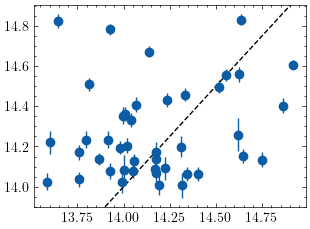

In [47]:
plt.figure()
plt.errorbar(model.matched_logM, model.matched_logY + 14, yerr=model.matched_sigma_logY, fmt='o', label='Matched clusters')

plt.axline((14, 14), slope=1, color='k', linestyle='--', label='y=x')

plt.show()

In [48]:
# 3. Set up MCMC sampler
nuts_kernel = NUTS(model)
mcmc = MCMC(
    nuts_kernel,
    num_warmup=500,
    num_samples=5000,
    num_chains=1,
    progress_bar=True,
)

mcmc.run(
    jax.random.PRNGKey(0),
    # dcz_allowed=1000,
)

samples = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████| 5500/5500 [00:01<00:00, 3298.79it/s, 7 steps of size 9.38e-02. acc. prob=0.93] 


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
      alpha     -0.49      0.15     -0.47     -0.71     -0.27   1143.87      1.00
       beta      0.61      0.10      0.60      0.45      0.77   1326.93      1.00
        eps      0.01      0.01      0.00      0.00      0.01   1907.97      1.00
  sigma_int      0.47      0.04      0.47      0.42      0.53   1259.89      1.00

Number of divergences: 0


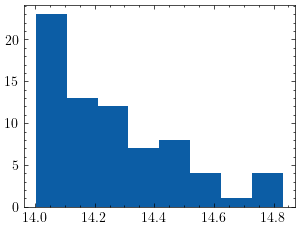

In [49]:
plt.figure()
plt.hist(np.log10(clusters["Y"]), bins="auto")
plt.show()

In [50]:
groups = cmbo.match.partition_volume(halos, clusters, linking_length=4)

  Group 1187: 2 clusters, 0 halos
    Cluster 0: nearest halo 287, distance 4.57 Mpc/h
    Cluster 1: nearest halo 287, distance 7.37 Mpc/h
  Group 1188: 1 clusters, 0 halos
    Cluster 6: nearest halo 223, distance 4.23 Mpc/h
  Group 1189: 1 clusters, 0 halos
    Cluster 8: nearest halo 231, distance 7.17 Mpc/h
  Group 1190: 1 clusters, 0 halos
    Cluster 9: nearest halo 231, distance 4.43 Mpc/h
  Group 1191: 1 clusters, 0 halos
    Cluster 11: nearest halo 139, distance 5.49 Mpc/h
  Group 1192: 1 clusters, 0 halos
    Cluster 12: nearest halo 189, distance 4.74 Mpc/h
  Group 1193: 1 clusters, 0 halos
    Cluster 13: nearest halo 705, distance 4.00 Mpc/h
  Group 1194: 1 clusters, 0 halos
    Cluster 14: nearest halo 398, distance 7.84 Mpc/h
  Group 1195: 1 clusters, 0 halos
    Cluster 15: nearest halo 66, distance 5.10 Mpc/h
  Group 1196: 1 clusters, 0 halos
    Cluster 16: nearest halo 970, distance 7.68 Mpc/h
  Group 1197: 1 clusters, 0 halos
    Cluster 19: nearest halo 15, dista

In [51]:
# ks = [36, 37, 38, 39]
ks = [62, 63, 64, 66, 67, ]

print("logY = ", np.log10(clusters["Y"][ks]))
print("Z = ", clusters["Z"][ks])
print("GLON = ", clusters["GLON"][ks])
print("GLAT = ", clusters["GLAT"][ks])

logY =  [14.33061667 14.04453976 14.60702588 14.45833563 14.17026172]
Z =  [0.02795849 0.0246237  0.01598206 0.04975813 0.04428866]
GLON =  [355.50377414 350.43903238 325.2522008  345.82603209 345.65628946]
GLAT =  [ 54.79489816  30.57770195  -7.11429934 -34.28877616 -39.30986199]


In [52]:
cmbo.match.print_group_summary(groups)

Total groups: 1184
Total halos: 1260
Total clusters: 31

Total associations: 1310
Total observed-halo pair evaluations: 50
Total virtual-halo pair evaluations: 1558

Groups by number of halos:
N_halos    N_groups  
--------------------
1          1120      
2          53        
3          10        
4          1         


In [53]:
data = cmbo.match.MatcherData(halos, clusters, groups)

sky_mask_interp = cmbo.match.MaskedSkyInterpolator(
    halos["GLON"], halos["GLAT"], b_lim=5, sigma_min=0.1, sigma_max=15,
    nside=128)

matcher = cmbo.match.ProbabilisticMatcher(
    cz_max=0.05 * cmbo.constants.SPEED_OF_LIGHT_KMS,
    # logY_lim=14.0,
    logY_lim=np.log10(1e14),
    # logY_lim=43.5,
    sky_mask_interpolator=sky_mask_interp,
    logM_piv=14.0,
    logY_piv=14.0,
    # logY_piv=44.,

)

Pairing groups: 100%|██████████| 1184/1184 [00:00<00:00, 9026.45it/s]


2025-12-14 00:13:59 Precomputing grid for 1263 halos, 101 σ values...


100%|██████████| 1263/1263 [00:17<00:00, 71.22it/s]


In [54]:
obs_inputs, virt_inputs = matcher.prepare_model_inputs(data)

In [55]:
# 3. Set up MCMC sampler
nuts_kernel = NUTS(matcher.model)
mcmc = MCMC(
    nuts_kernel,
    num_warmup=500,
    num_samples=1000,
    num_chains=1,
    progress_bar=True,
    
)

In [56]:
mcmc.run(
    jax.random.PRNGKey(0),
    obs_inputs=obs_inputs,
    virt_inputs=virt_inputs,
    mass_dependent_genuineness=True,
    # dcz_allowed=1000,
)

sample: 100%|██████████| 1500/1500 [00:04<00:00, 304.15it/s, 15 steps of size 1.51e-01. acc. prob=0.91]


In [57]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
            alpha     -0.39      0.24     -0.36     -0.74      0.00    207.20      1.00
             beta      1.10      0.30      1.08      0.66      1.62    461.18      1.01
   f_genuine_high      0.45      0.20      0.41      0.16      0.79    311.68      1.01
  logM_transition     14.11      0.51     14.13     13.32     14.97    602.31      1.00
        sigma_int      0.40      0.12      0.38      0.23      0.58    175.40      1.00
      sigma_theta      0.47      0.06      0.47      0.37      0.55    929.26      1.00
          sigma_v    152.45     25.47    149.82    112.32    191.06    735.47      1.00
            width      0.56      0.26      0.55      0.19      1.00    660.04      1.00

Number of divergences: 0


In [37]:
samples = mcmc.get_samples()
# mcmc.print_summary()

/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_45088/3219764419.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


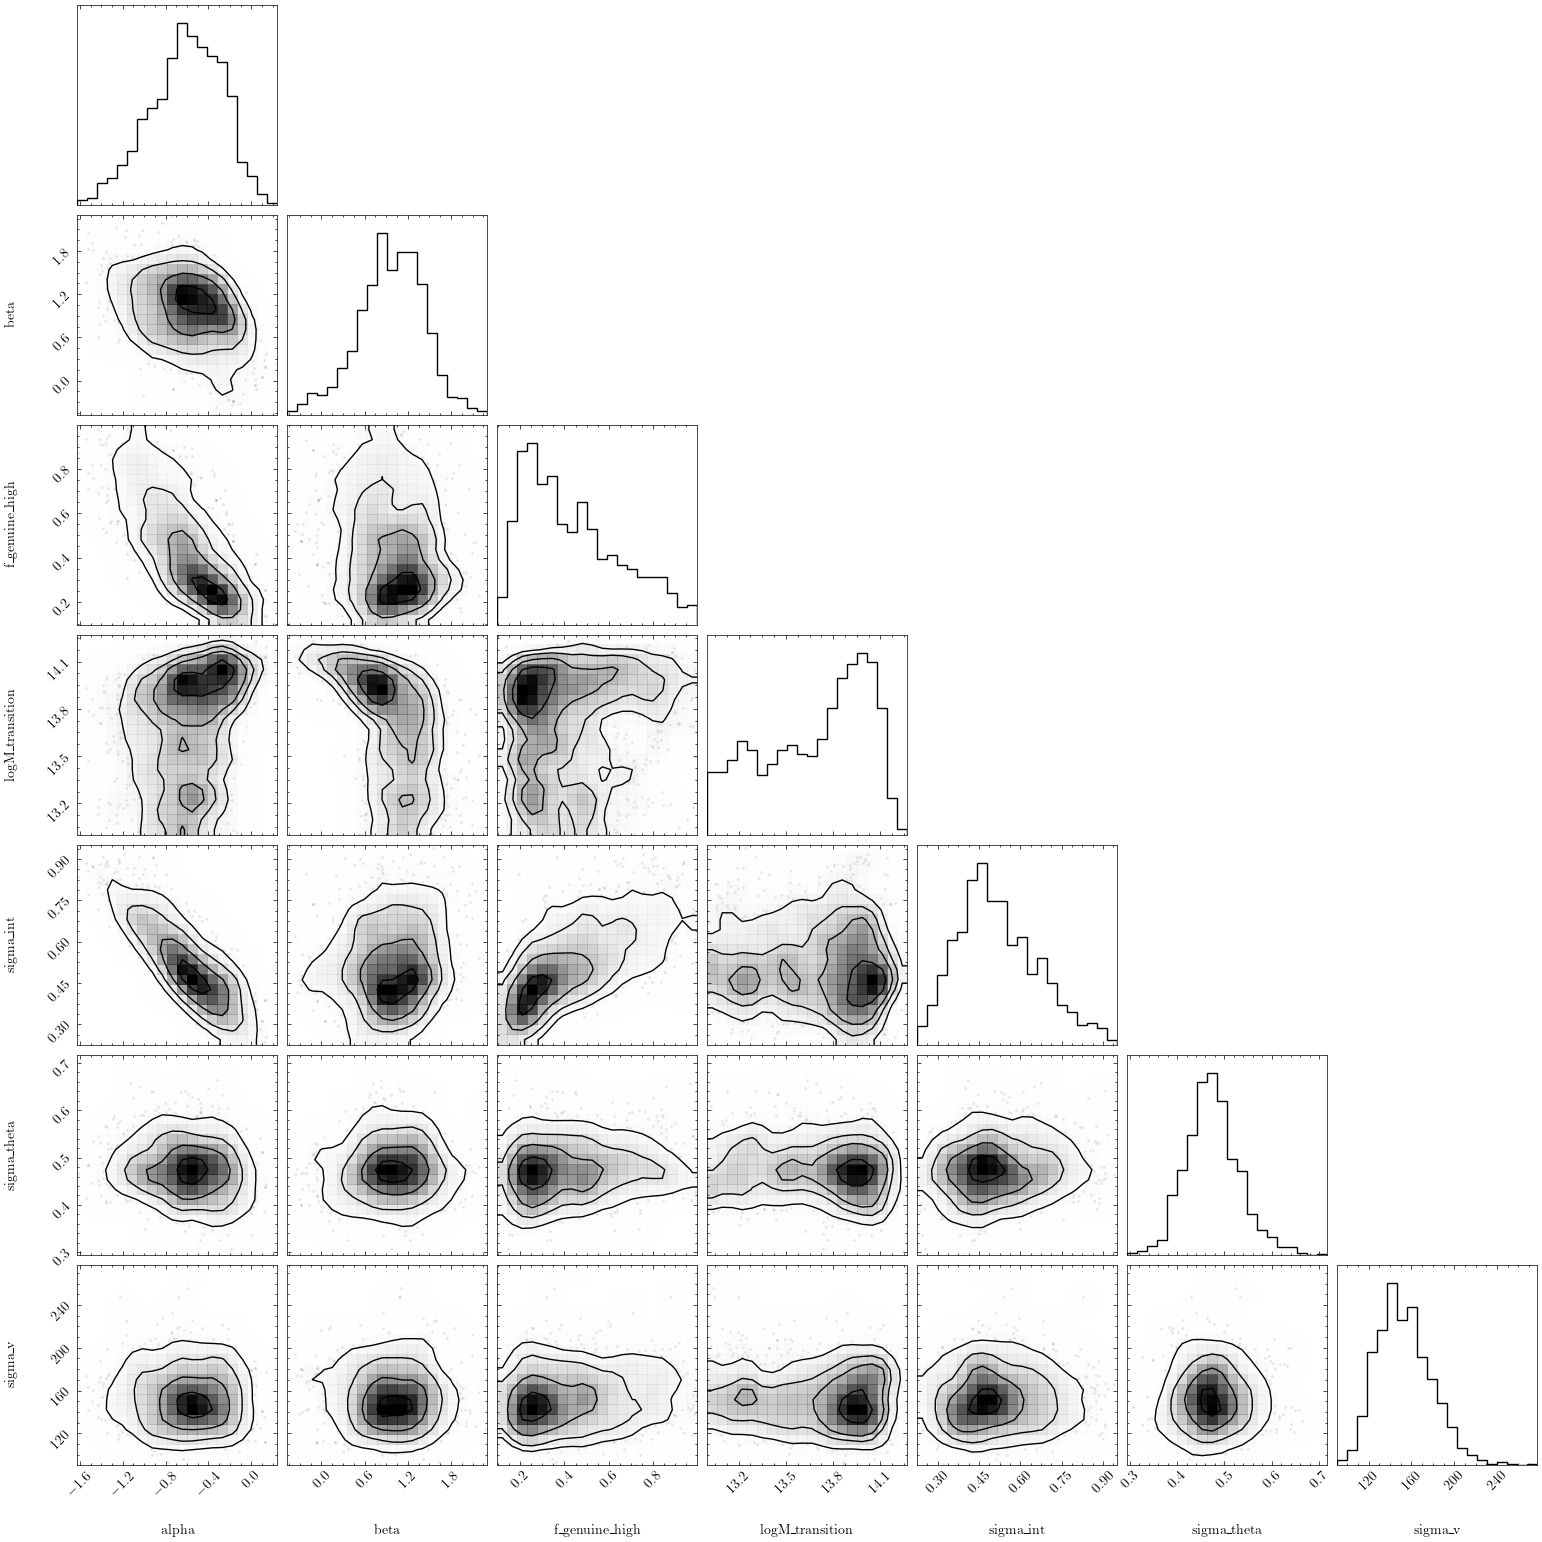

In [38]:
X = np.vstack([samples[k] for k in samples.keys()]).T

from corner import corner

fig = corner(data=X, smooth=1, labels=list(samples.keys()))
fig.show()

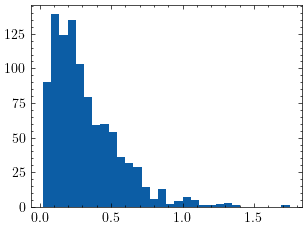

In [39]:
plt.figure()
plt.hist(10**samples["alpha"], bins="auto")
plt.show()

In [75]:




#   # 5. Get results
#   mcmc.print_summary()
#   samples = mcmc.get_samples()

#   # 6. Access posterior samples
#   alpha_Y = samples['alpha_Y']
#   beta_Y = samples['beta_Y']
#   sigma_int = samples['sigma_int']
#   sigma_theta_deg = samples['sigma_theta_deg']
#   sigma_v = samples['sigma_v']

#   Key parameters to set:
#   - Y_lim: Your survey's detection threshold
#   - f_det: Completeness fraction (0-1)
#   - b_cut: Zone of avoidance galactic latitude cut
#   - num_warmup: MCMC warmup iterations
#   - num_samples: Posterior samples to draw
#   - num_chains: Number of parallel chains

#   The model will sample:
#   - alpha_Y: Scaling relation intercept
#   - beta_Y: Scaling relation slope
#   - sigma_int: Intrinsic scatter
#   - sigma_theta_deg: Angular scatter (degrees)
#   - sigma_v: Velocity scatter (km/s)

In [83]:
x_halo

array([[225.3946991 , 293.26654053, 263.47869873],
       [328.25634766, 317.63226318, 295.6867981 ],
       [387.57635498, 386.72616577, 407.82092285],
       [277.69332886, 324.27426147, 375.15670776],
       [378.99160767, 292.7734375 , 481.07354736],
       [364.72085571, 368.49920654, 373.03213501],
       [317.93746948, 279.51882935, 205.82453918],
       [291.45010376, 252.66186523, 370.39453125],
       [398.9041748 , 278.42166138, 230.1071167 ],
       [433.19955444, 271.36886597, 415.51739502],
       [309.32614136, 250.87609863, 231.81642151],
       [312.72244263, 274.20742798, 401.24249268],
       [406.01217651, 202.36688232, 353.33972168],
       [462.94937134, 371.46292114, 338.12341309],
       [255.60346985, 296.87426758, 278.76391602],
       [208.02180481, 309.14990234, 303.4296875 ],
       [330.45684814, 431.22158813, 213.98803711],
       [342.35269165, 447.44311523, 251.30784607],
       [445.26239014, 402.8899231 , 338.90325928],
       [419.59176636, 246.03155

(2493,) (2493,) (2493,)
(820,) (820,) (820,) (820,)


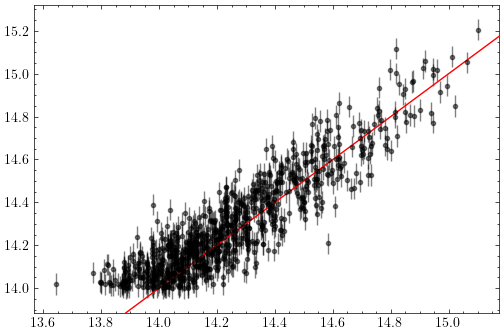

In [ ]:
mockgen = MockGenerator()

mock_kwargs = {
    "log_mmin": 13,
    "log_mmax": 16,
    "volume": 500**3,
    "log_m_cut_true": None,
    "log_m_cut_obs": 14,
    "scatter_dex": 0.1,
    "meas_err_dex": 0.05,
}

x, y, yerr = mockgen.make_mock(**mock_kwargs, seed=1)
print(x.shape, y.shape, yerr.shape)

x, y, yerr, pmatch = mockgen.simulate_incomplete_matching(
    x, y, yerr, completeness=0.76, mass_dependent=True, mass_scale=14.3,
    use_observed=True)
print(x.shape, y.shape, yerr.shape, pmatch.shape)

xmean = x.mean()
x -= xmean

truths = [0 + xmean, 0.1, 1.0]


plt.figure(figsize=(6, 4))
plt.errorbar(x + xmean, y, yerr=yerr, fmt=".k", alpha=0.5)

plt.axline([14.4, 14.4], slope=1, color='red')

plt.show()


In [ ]:
fitter = ScalingRelationFitter()

mcmc = fitter.fit(
    x, y, yerr, ymin=mock_kwargs["log_m_cut_obs"],
    num_warmup=1000, num_samples=2500,
    completeness=0.76, match_on_y=True, mass_scale=14.3)
mcmc.print_summary()
samples = mcmc.get_samples()


sample: 100%|██████████| 3500/3500 [00:01<00:00, 2592.51it/s, 1 steps of size 2.23e-308. acc. prob=0.00]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  intercept    -50.00      0.00    -50.00    -50.00    -50.00       nan       nan
      sigma      0.50      0.00      0.50      0.50      0.50       nan       nan
      slope      2.00      0.00      2.00      2.00      2.00      1.00      1.00

Number of divergences: 2500


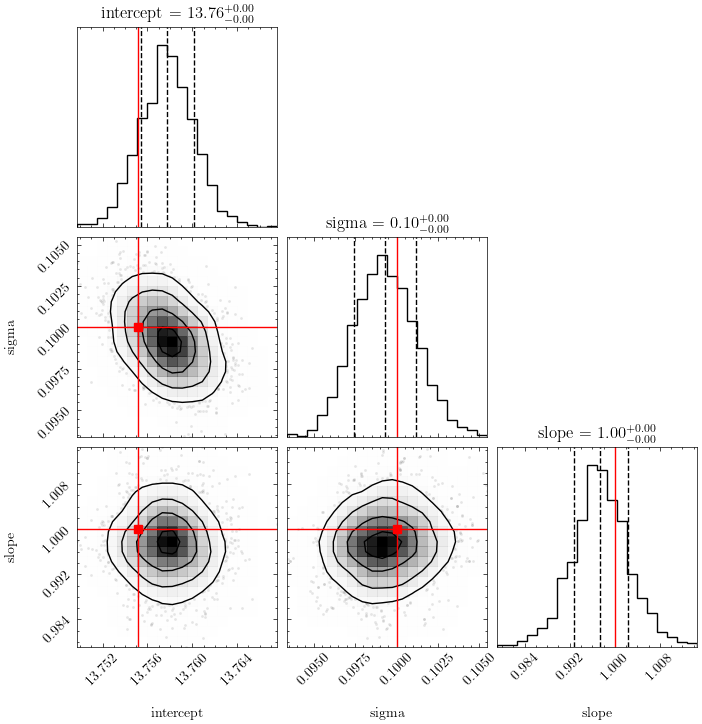

In [ ]:
fig = make_corner_plot(samples, truths=truths)

display(fig)

In [ ]:
cfg = cmbo.utils.load_config("/Users/rstiskalek/Projects/CMBOlympics/scripts/config.toml")
data_MCXC = cmbo.io.load_mcxc_catalogue(cfg['paths']['MCXC_catalogue'])

In [ ]:
logL = np.log10(data_MCXC["L500"] * 0.68)
elogL = data_MCXC["eL500"] / (data_MCXC["L500"] * np.log(10))


x_obs = cmbo.utils.radec_to_cartesian(data_MCXC['RA'], data_MCXC['DEC'])
x_obs *= cmbo.utils.cz_to_comoving_distance(data_MCXC['Z'] * cmbo.constants.SPEED_OF_LIGHT_KMS)[:, None]

mask = (data_MCXC['M500'] >= 1e14) & (data_MCXC['Z'] <= 0.05)
x_obs = x_obs[mask]
x_obs += 681.1 / 2

x_halo, masses = cmbo.io.load_halo_positions_masses(
    "/Users/rstiskalek/Projects/CMBOlympics/data/manticore_fof.hdf5",
    "Coordinates", "Group_M_Crit200", nsim=0, r_max=1000, mass_min=1e10
    )



In [ ]:
x_halo, masses = cmbo.io.load_halo_positions_masses(
    "/Users/rstiskalek/Projects/CMBOlympics/data/manticore_fof.hdf5",
    "Coordinates", "Group_M_Crit200", nsim=0, r_max=1000, mass_min=1e10
    )


# x_halo = x_obs + 0.1


In [ ]:
np.savez("matching_halos_data.npz", x_halo=x_halo, masses=masses)

In [ ]:
np.savez("matching_halos_data.npz", x_halo=x_halo, x_obs=x_obs, logL=logL[mask], elogL=elogL[mask], halo_masses=masses, xray_masses=data_MCXC['M500'][mask])

In [ ]:
x_halo.shape

In [ ]:
groups = cmbo.match.fof_tessellation(x_obs, x_halo, linking_length=3)
groups_prob = cmbo.match.compute_group_probabilities(x_obs, x_halo, 1, groups)

In [ ]:
# model = cmbo.match.AssociationModel(groups, groups_prob)

model = cmbo.match.ScalingRelationModel(groups, groups_prob, logL - 44, 0.01 * elogL, logL - 44 + 0.01)

In [ ]:
mcmc = model.run()
mcmc.print_summary()
samples = mcmc.get_samples()

In [ ]:
plt.figure()
plt.hist(samples['p_null'], bins=30)
plt.show()

In [ ]:
matches = model.get_best_matches(samples['p_null'])
matches

In [ ]:
results = model.get_association_probabilities(samples['p_null'])

In [ ]:
results

In [ ]:
plt.figure()
plt.hist(samples["p_null"], bins="auto")
plt.show()

In [ ]:
# total = 0
# for obs_idx, halo_idx in groups:
#     n_assignments = len(cmbo.match.generate_valid_assignments(len(obs_idx), len(halo_idx)))
#     total += n_assignments
#     print(f"Group ({len(obs_idx)} obs, {len(halo_idx)} halos): {n_assignments} assignments")

# print(f"Total assignments: {total}")


In [ ]:
res[1]

In [ ]:
groups[1]

In [ ]:
sum([len(gr[1]) for gr in groups])

In [ ]:
len(x_halo)

In [ ]:
len(x_obs)

In [ ]:
groups[0]